In [30]:
from langchain_mistralai import ChatMistralAI
from typing import List, Optional,TypedDict,Annotated
from pydantic import BaseModel, Field
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langgraph.graph import StateGraph,START,END
from dotenv import load_dotenv
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver


load_dotenv()


True

In [31]:
checkpoint = MemorySaver()

In [3]:
llm = ChatMistralAI()

In [14]:
#add the messages to the graph

class chatstate (TypedDict): 

    messages: Annotated[List[BaseMessage],add_messages]

In [8]:
def chat_nodes(state: chatstate):

   messages = state['messages']

   reponse = llm.invoke(messages)

   return {"messages": reponse}

In [33]:
graph = StateGraph(chatstate)

graph.add_node(chat_nodes,"chat_nodes")


graph.add_edge(START, "chat_nodes")
graph.add_edge("chat_nodes", END)

chat_model = graph.compile(checkpointer=checkpoint)

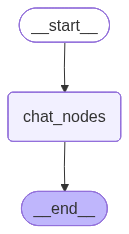

In [17]:
chat_model

In [26]:
inital_state = {"messages": [HumanMessage(content="what is the beautifull place in it ?")]}

In [27]:
response = chat_model.invoke(inital_state)

response['messages'][1].content

'If you\'re asking about **Italy**, it\'s one of the most beautiful and culturally rich countries in the world, with countless stunning destinations. Here are some of the **most breathtaking places** in Italy:\n\n### **1. Amalfi Coast** 🌊\n   - **Positano** – A colorful cliffside village with pastel houses, lemon groves, and stunning sea views.\n   - **Capri** – A glamorous island with the **Blue Grotto**, luxury villas, and dramatic cliffs.\n   - **Ravello** – A serene hilltop town with breathtaking views of the Tyrrhenian Sea.\n\n### **2. Tuscany (Val d’Orcia & Florence)** 🏡\n   - **Val d’Orcia** – Rolling hills, vineyards, and medieval farmhouses (perfect for *Under the Tuscan Sun*).\n   - **Florence** – The heart of the Renaissance, with the **Duomo**, **Uffizi Gallery**, and **Ponte Vecchio**.\n   - **Siena** – A medieval gem with the **Piazza del Campo** (famous for the Palio horse race).\n   - **San Gimignano** – A medieval "Manhattan" with towering stone buildings.\n\n### **3. 

In [37]:
thread_id = "1"

while True:

    user_input = input("User: ")

    print("user", user_input)

    

    if user_input.lower().strip() in ["exit", "quit", "q"]:
        break

    config  = {"configurable" : {"thread_id": thread_id}}

    inital_state = {"messages": [HumanMessage(content=user_input)]}

    response = chat_model.invoke(inital_state,config = config)

    print("AI:", response['messages'][-1].content)

user what is my name 
AI: Your name is **Raj**! 😊
user q


In [38]:
chat_model.get_state(config  = config)

StateSnapshot(values={'messages': [HumanMessage(content='my name is raj ', additional_kwargs={}, response_metadata={}, id='d2963ded-eb78-46dd-95c2-38f989a5e994'), AIMessage(content='Hello Raj! 😊 How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'prompt_tokens': 20, 'total_tokens': 34, 'completion_tokens': 14, 'prompt_tokens_details': {'cached_tokens': 0}}, 'model_name': 'mistral-small', 'model': 'mistral-small', 'finish_reason': 'stop', 'model_provider': 'mistralai'}, id='lc_run--019e7cbc-085e-7ba2-a988-fb1a232cb0c2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 20, 'output_tokens': 14, 'total_tokens': 34}), HumanMessage(content='iam working on painter ', additional_kwargs={}, response_metadata={}, id='896c5e37-13d2-4f83-937c-8b270ea6c637'), AIMessage(content="That sounds interesting! Painting can be a great creative outlet or even a profession. Are you working on a specific painting project, or are you exploring painting 